# 000978 stage 5 — intrinsic dimensionality (triangulated)

From `src/000978/06_dimensionality.py` on the smoothed 50 ms **run-epoch** data
(shared estimators in `src/common/dimensionality.py`; ZT2 excluded). Same four
estimators as 000447 — **TwoNN**, **PCA participation ratio**, **Isomap knee**,
and **decoding-vs-dimension** — but the decoded task label here is the **run
session** (how many dimensions carry the within-day learning drift).

## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir
DATA_PROCESSED = processed_dir("000978")
plt.rcParams["figure.dpi"] = 100
summ = pd.read_csv(DATA_PROCESSED / "stage5_dim_summary.csv")
curves = pd.read_csv(DATA_PROCESSED / "stage5_dim_curves.csv")
print("files x region:", len(summ))
summ.groupby("region")[["twonn", "participation_ratio", "isomap_knee",
                        "decode_pos_sat", "decode_label_sat"]].median().round(1)

files x region: 14


,twonn,participation_ratio,isomap_knee,decode_pos_sat,decode_label_sat
region,,,,,
CA1,8.3,11.6,5.0,14.0,11.0
PFC,8.0,9.9,5.0,13.0,11.0


## 1. Triangulated dimensionality per file × region

TwoNN (green, ± bootstrap sd) and Isomap knee (cyan) — intrinsic — vs. the linear
PCA participation ratio (purple). Pooling the whole day's run sessions, the
intrinsic dimension is higher than 000447 (the learning drift adds dimensions).

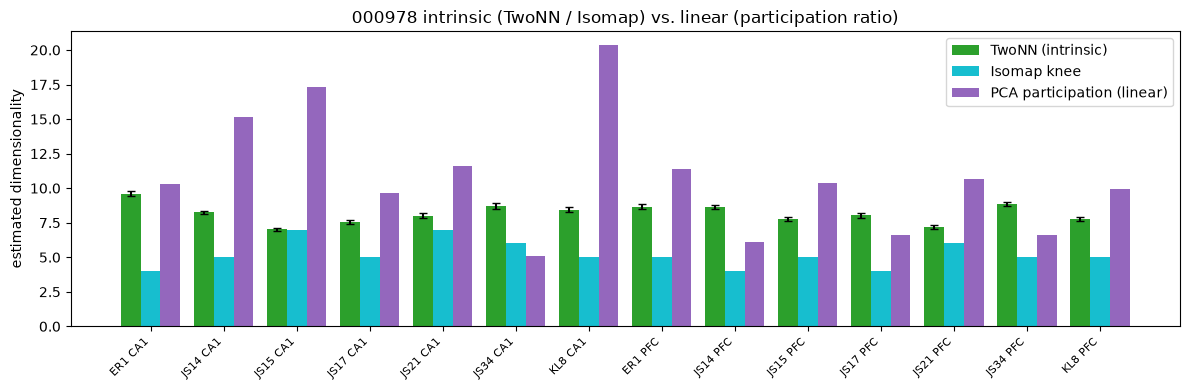

In [2]:
a = summ.copy()
a["label"] = a.session_key + " " + a.region
a = a.sort_values(["region", "session_key"])
x = np.arange(len(a)); w = 0.27
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w, a.twonn, w, yerr=a.twonn_sd, capsize=3, label="TwoNN (intrinsic)", color="tab:green")
ax.bar(x, a.isomap_knee, w, label="Isomap knee", color="tab:cyan")
ax.bar(x + w, a.participation_ratio, w, label="PCA participation (linear)", color="tab:purple")
ax.set_xticks(x); ax.set_xticklabels(a.label, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("estimated dimensionality"); ax.legend()
ax.set_title("000978 intrinsic (TwoNN / Isomap) vs. linear (participation ratio)")
plt.tight_layout()

## 2. Decoding vs. dimension

CV decoding (mean over files × regions) vs. PCA latent dimension: position R² and
run-session classification accuracy. Session identity needs more dimensions than
position — the learning drift is spread across the manifold.

,decode_pos_sat,decode_label_sat
region,,
CA1,14.0,11.0
PFC,13.0,11.0


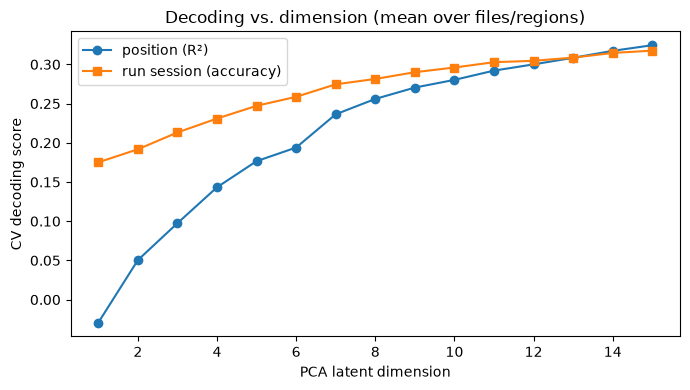

In [3]:
mp = curves.groupby("dim")[["decode_pos", "decode_label"]].mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mp.index, mp.decode_pos, "-o", color="tab:blue", label="position (R\u00b2)")
ax.plot(mp.index, mp.decode_label, "-s", color="tab:orange", label="run session (accuracy)")
ax.set_xlabel("PCA latent dimension"); ax.set_ylabel("CV decoding score")
ax.set_title("Decoding vs. dimension (mean over files/regions)"); ax.legend()
plt.tight_layout()
summ.groupby("region")[["decode_pos_sat", "decode_label_sat"]].median().round(1)

## 3. The curvature gap

TwoNN intrinsic dimension vs. linear participation ratio, one point per file×
region. Above the diagonal = linear over-counting (curvature).

,twonn,participation_ratio
region,,
CA1,8.2,12.8
PFC,8.1,8.8


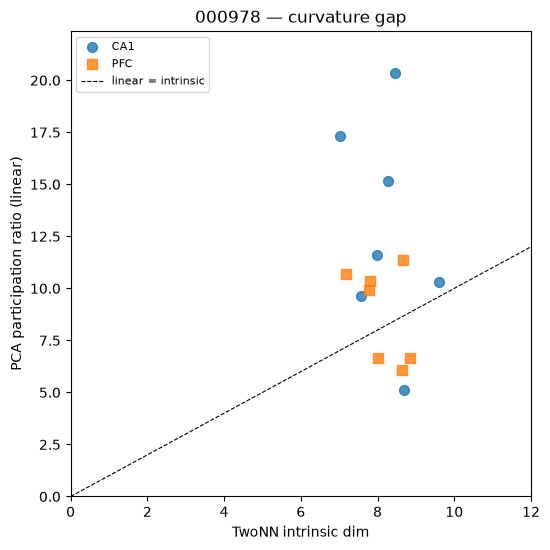

In [4]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
for region, mk in [("CA1", "o"), ("PFC", "s")]:
    r = summ[summ.region == region]
    ax.scatter(r.twonn, r.participation_ratio, marker=mk, s=50, alpha=0.8, label=region)
lim = [0, summ.participation_ratio.max() * 1.1]
ax.plot(lim, lim, "k--", lw=0.8, label="linear = intrinsic")
ax.set_xlim(0, max(12, summ.twonn.max() * 1.1)); ax.set_ylim(0, lim[1])
ax.set_xlabel("TwoNN intrinsic dim"); ax.set_ylabel("PCA participation ratio (linear)")
ax.set_title("000978 — curvature gap"); ax.legend(fontsize=8)
plt.tight_layout()
summ.groupby("region")[["twonn", "participation_ratio"]].mean().round(1)

## 4. Does dimensionality change as the animal learns?

Dimensionality estimated **per run session** (not pooled), across the learning
day: TwoNN intrinsic dimension (left) and linear participation ratio (right),
mean ± sem over the 7 animals, CA1 vs. PFC. Read alongside 6b (the manifold's
geometry converges toward the final session) — this asks whether its
*dimensionality* also drifts, or whether learning reshapes a fixed-dimensional
map.

twonn  participation_ratio
region session                            
CA1    1          3.1                 12.0
       2          3.1                 12.0
       3          3.2                 11.6
       4          3.3                 11.1
       5          3.4                 11.2
       6          3.6                 11.5
       7          3.4                 12.0
       8          3.3                 12.1
PFC    1          3.4                  8.3
       2          3.3                  8.4
       3          3.4                  8.1
       4          3.5                  7.7
       5          3.6                  7.5
       6          3.7                  8.3
       7          3.6                  8.4
       8          3.5                  8.5

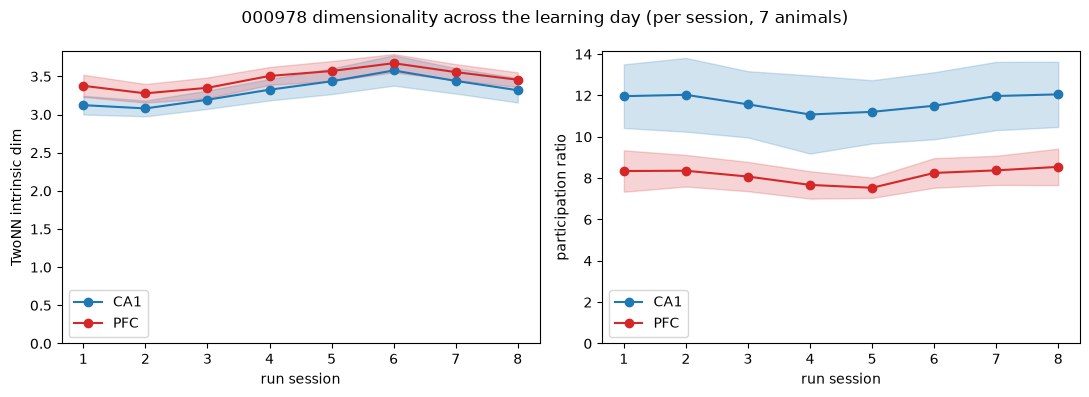

In [5]:
bysess = pd.read_csv(DATA_PROCESSED / "stage5_dim_by_session.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for metric, ax, ylab in [("twonn", axes[0], "TwoNN intrinsic dim"),
                         ("participation_ratio", axes[1], "participation ratio")]:
    for region, cc in [("CA1", "tab:blue"), ("PFC", "tab:red")]:
        g = bysess[bysess.region == region].groupby("session")[metric].agg(["mean", "sem"])
        ax.plot(g.index, g["mean"], "-o", color=cc, label=region)
        ax.fill_between(g.index, g["mean"] - g["sem"], g["mean"] + g["sem"], color=cc, alpha=0.2)
    ax.set_xlabel("run session"); ax.set_ylabel(ylab); ax.set_ylim(bottom=0); ax.legend()
fig.suptitle("000978 dimensionality across the learning day (per session, 7 animals)")
plt.tight_layout()
bysess.groupby(["region", "session"])[["twonn", "participation_ratio"]].mean().round(1)

## 5. Low-dimensional but drifting across sessions

Section 4 showed each session is low-D (~3) yet pooling gives ~8. Here we show
directly that the extra pooled dimensions are **drift** of the low-D subspace
(from `src/000978/06_dim_drift.py`, 50 ms run epochs):

- **Cross-session subspace generalization** (heatmap): the top-3 PCs of session
  *i* explain session *i* well (bright diagonal ⇒ low-D) but explain distant
  sessions progressively less (off-diagonal decay ⇒ the subspace rotates).
- **Cumulative dimensionality**: participation ratio of the pooled first-*n*
  sessions rises with *n* for the real data but stays flat for a session-label
  shuffle — so pooling adds dimensions only because of genuine session structure.
- **Subspace overlap vs session gap**: variance explained falls monotonically
  with |i − j| — a gradual drift, consistent with the 6b convergence.

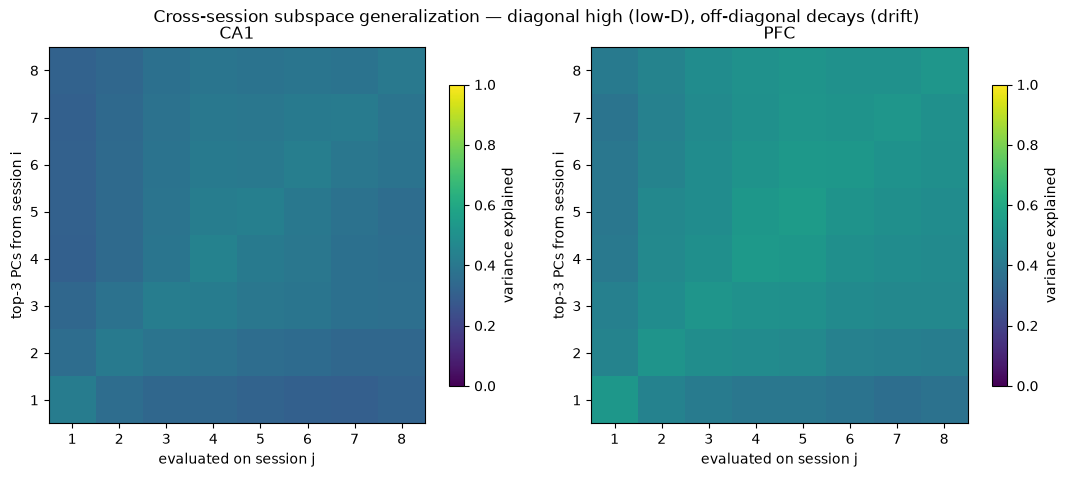

In [6]:
heat = pd.read_csv(DATA_PROCESSED / "stage5_drift_heatmap.csv")
sessions = sorted(heat.i.unique())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, region in zip(axes, ["CA1", "PFC"]):
    M = (heat[heat.region == region].groupby(["i", "j"]).ve.mean()
         .unstack("j").reindex(index=sessions, columns=sessions))
    im = ax.imshow(M.values, origin="lower", cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(sessions))); ax.set_xticklabels(sessions)
    ax.set_yticks(range(len(sessions))); ax.set_yticklabels(sessions)
    ax.set_xlabel("evaluated on session j"); ax.set_ylabel("top-3 PCs from session i")
    ax.set_title(region)
    fig.colorbar(im, ax=ax, shrink=0.8, label="variance explained")
fig.suptitle("Cross-session subspace generalization — diagonal high (low-D), off-diagonal decays (drift)")
plt.tight_layout()

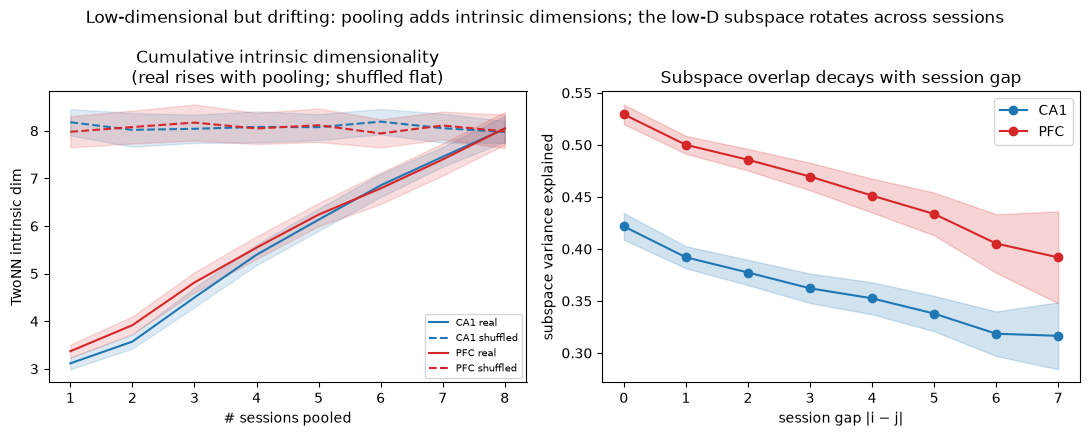

In [7]:
# Drift quantified: cumulative dimensionality (real vs shuffled) + subspace overlap vs gap
cum = pd.read_csv(DATA_PROCESSED / "stage5_drift_cumulative.csv")
heat["gap"] = (heat.i - heat.j).abs()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for region, cc in [("CA1", "tab:blue"), ("PFC", "tab:red")]:
    for kind, ls in [("real", "-"), ("shuffled", "--")]:
        g = cum[(cum.region == region) & (cum.kind == kind)].groupby("n_sessions").twonn.agg(["mean", "sem"])
        axes[0].plot(g.index, g["mean"], ls, color=cc, label=f"{region} {kind}")
        axes[0].fill_between(g.index, g["mean"] - g["sem"], g["mean"] + g["sem"], color=cc, alpha=0.15)
axes[0].set_xlabel("# sessions pooled"); axes[0].set_ylabel("TwoNN intrinsic dim")
axes[0].set_title("Cumulative intrinsic dimensionality\n(real rises with pooling; shuffled flat)")
axes[0].legend(fontsize=7)
for region, cc in [("CA1", "tab:blue"), ("PFC", "tab:red")]:
    g = heat[heat.region == region].groupby("gap").ve.agg(["mean", "sem"])
    axes[1].plot(g.index, g["mean"], "-o", color=cc, label=region)
    axes[1].fill_between(g.index, g["mean"] - g["sem"], g["mean"] + g["sem"], color=cc, alpha=0.2)
axes[1].set_xlabel("session gap |i − j|"); axes[1].set_ylabel("subspace variance explained")
axes[1].set_title("Subspace overlap decays with session gap"); axes[1].legend()
fig.suptitle("Low-dimensional but drifting: pooling adds intrinsic dimensions; the low-D subspace rotates across sessions")
plt.tight_layout()

---
**Takeaway:** the awake W-track manifold is low-dimensional and curved here too,
but with a higher intrinsic dimension than 000447 — pooling the whole day's run
sessions, the learning drift itself occupies extra dimensions (run-session
decoding needs more PCA dimensions than position). This is consistent with 6b,
where the manifold moves session-to-session before converging.